In [77]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score

In [78]:
car_df=pd.read_csv("cars.csv")

In [79]:
car_df

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


In [80]:
#Basic EDA

In [81]:
car_df.shape

(81, 5)

In [82]:
car_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HP      81 non-null     int64  
 1   MPG     81 non-null     float64
 2   VOL     81 non-null     int64  
 3   SP      81 non-null     float64
 4   WT      81 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 3.3 KB


In [83]:
car_df.columns

Index(['HP', 'MPG', 'VOL', 'SP', 'WT'], dtype='str')

In [84]:
car_df.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


In [85]:
car_df.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [86]:
car_df.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [87]:
car_df.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
76    False
77    False
78    False
79    False
80    False
Length: 81, dtype: bool

In [88]:
car_df.value_counts()

HP   MPG        VOL  SP          WT       
49   53.700681  89   104.185353  28.762059    1
55   50.013401  92   105.461264  30.466833    1
                                 30.193597    1
70   45.696322  92   113.461264  30.632114    1
53   50.504232  92   104.461264  29.889149    1
                                             ..
322  36.900000  50   169.598513  16.132947    1
238  19.197888  115  150.576579  37.923113    1
263  34.000000  50   151.598513  15.769625    1
295  19.833733  119  167.944460  39.423099    1
236  12.101263  107  139.840817  34.948615    1
Name: count, Length: 81, dtype: int64

In [89]:
#Check distribution

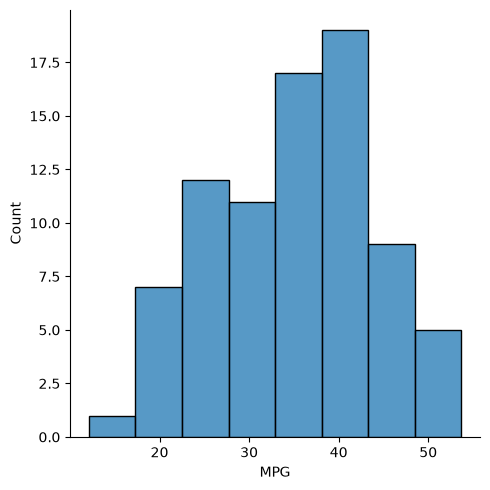

In [90]:
sns.displot(data=car_df["MPG"])
plt.show()

In [91]:
#Assumptions
#Linearity # positive or negative linearity
#Multicolinearity
#Auto Regression
#Homoscedasticity
#Zero Residual Mean

# Linearity there should be a strong relationship B/w inpendent and dependent variables 

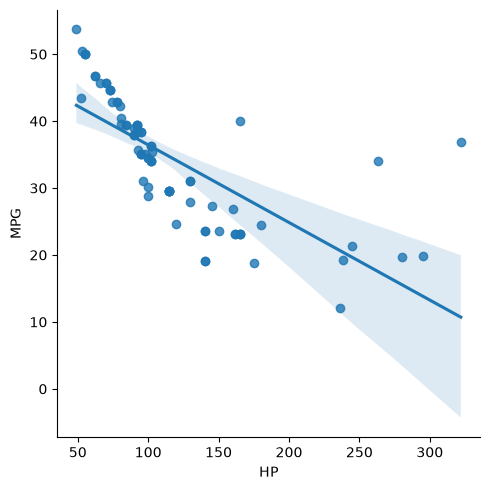

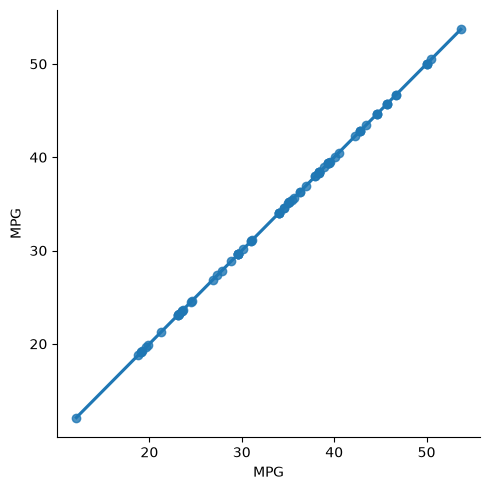

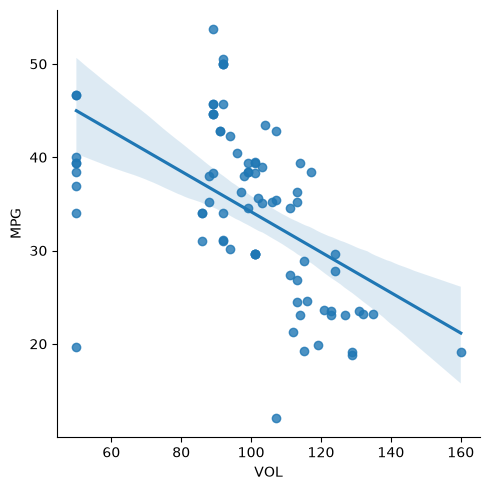

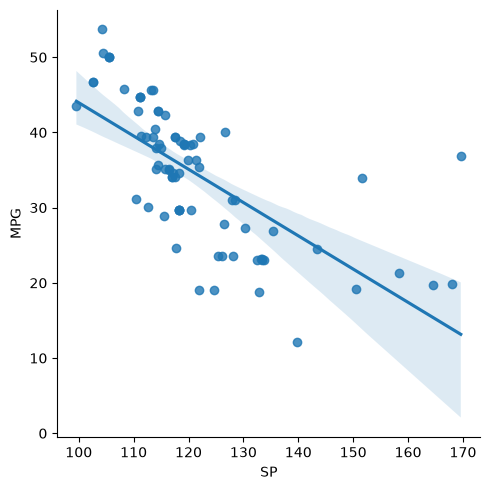

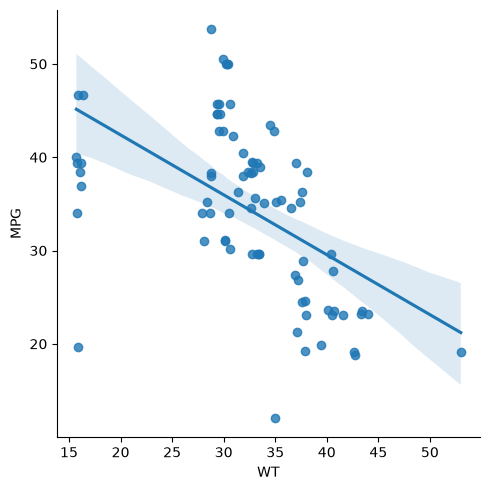

In [92]:
for i in car_df.columns:
    sns.lmplot(data=car_df,x=i,y="MPG")

In [93]:
# above plot shows MPG has negative linearity with independent features, shows not enough strong relationship
# Linearity Failed

# Multicolinearity ----> there should not be a relationship B/W independent features, 

In [94]:
car_df.corr()

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


<Axes: >

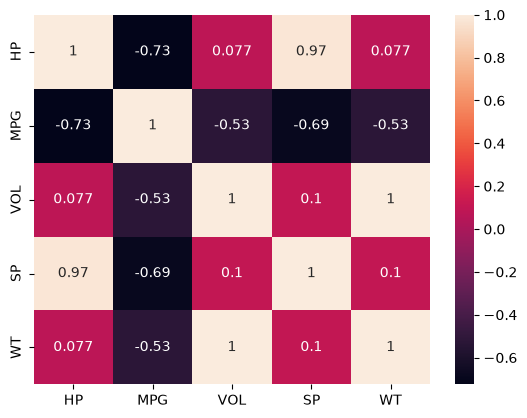

In [95]:
sns.heatmap(car_df.corr(),annot=True)

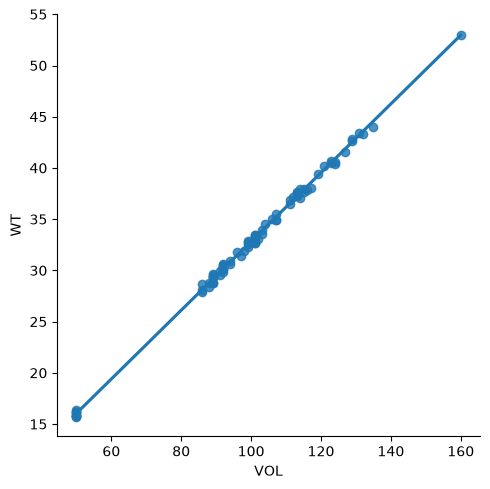

In [96]:
 sns.lmplot(data=car_df,x="VOL",y="WT")

In [97]:
#Multicolinearity Failed

# Auto Regression----> there should not be a time dependent data

In [98]:
#Auto Regression Passed

In [99]:
x=car_df.drop(labels="MPG",axis=1)
y=car_df[["MPG"]]

In [100]:
x

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [101]:
y

,MPG
0,53.700681
1,50.013401
2,50.013401
3,45.696322
4,50.504232
...,...
76,36.900000
77,19.197888
78,34.000000
79,19.833733


In [102]:
Model1=LinearRegression()

In [103]:
Model1.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 4)","[[-0.21,-0.34, 0.4 , 0.4 ]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['HP','VOL','SP','WT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[30.68]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [104]:
Model1.coef_

array([[-0.20544372, -0.33605084,  0.39562692,  0.40057409]])

In [105]:
Model1.intercept_

array([30.67733585])

In [106]:
y_pred=Model1.predict(x)

In [107]:
y_pred

array([[43.44193477],
       [42.38879289],
       [42.27934147],
       [42.53835981],
       [42.17264802],
       [43.02061916],
       [42.32536062],
       [48.07621852],
       [48.28120247],
       [40.79122814],
       [41.52153227],
       [47.80956747],
       [39.95980269],
       [41.52757889],
       [41.76632332],
       [41.6181448 ],
       [41.15094046],
       [47.98605515],
       [41.30861046],
       [37.87127922],
       [38.57706414],
       [37.35199705],
       [37.89770285],
       [39.5625144 ],
       [39.93380662],
       [46.73870908],
       [35.48165898],
       [38.78152504],
       [38.24861192],
       [36.00285298],
       [34.84603989],
       [37.21630246],
       [37.13919796],
       [34.82541399],
       [37.22361389],
       [37.53950097],
       [39.27144845],
       [38.24219888],
       [38.54286458],
       [35.9391722 ],
       [34.2129755 ],
       [35.36313259],
       [37.50473376],
       [38.07998482],
       [35.79651664],
       [36

# Evalution metrics for regression problem
Mean Absolute Error (MAE)
Mean Squared Error (MSE)
Root Mean Squared Error (RMSE)
R-squared (R²)


In [108]:
mean_absolute_error(y,y_pred)

3.267968285420799

In [109]:
r2_score(y,y_pred)

0.7705372737359844

In [110]:
#Zero Residual Mean----> the error mean value / residual mean value should be zero

In [111]:
error=y-y_pred

In [112]:
error

,MPG
0,10.258747
1,7.624608
2,7.734060
3,3.157963
4,8.331584
...,...
76,15.617904
77,1.298838
78,7.863547
79,7.517122


In [113]:
np.mean(error)

np.float64(3.50885301609926e-16)

In [114]:
x.shape

(81, 4)

In [115]:
#Zero Residual Mean Passed

# Homoscedasticity---> errors should be like constant variance

In [116]:
#Homoscedasticity Failed

# Data Transformation Techniques
## Regression
1. log transformation
2. Squre root transformation
3. cube root transformation
4. reciprocal transformation
5. standard scalar
6. Min, Max scalar

## Classification
1. one hot encoding
2. label encoding

In [117]:
car_df["Log_HP"]=np.log(car_df["HP"])
car_df["Log_SP"]=np.log(car_df["SP"])
car_df["Log_VOL"]=np.log(car_df["VOL"])
car_df["Log_WT"]=np.log(car_df["WT"])

In [118]:
x.shape

(81, 4)

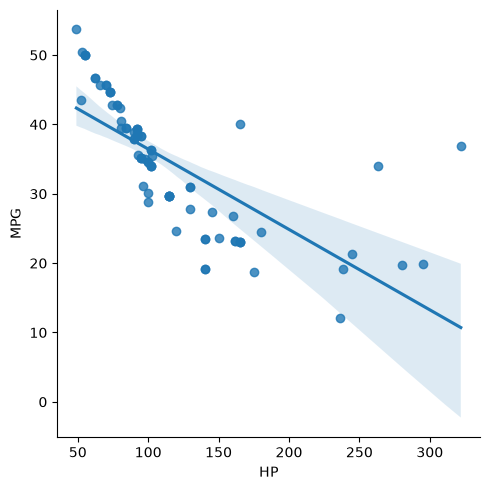

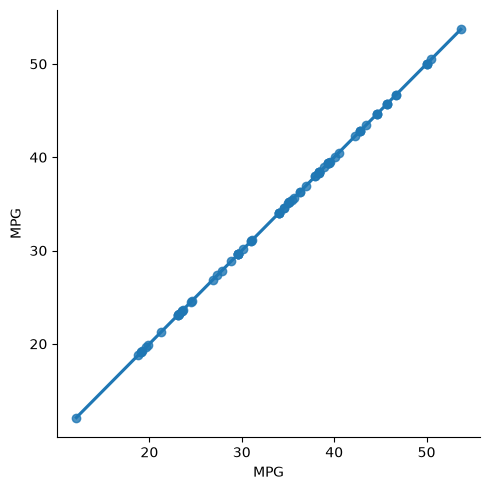

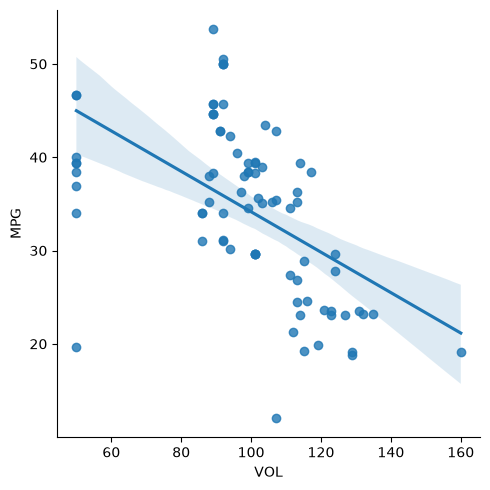

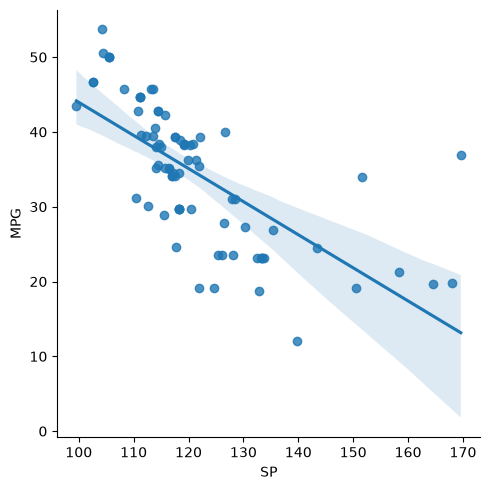

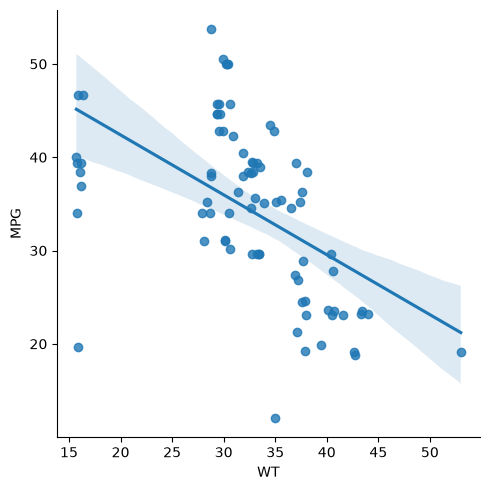

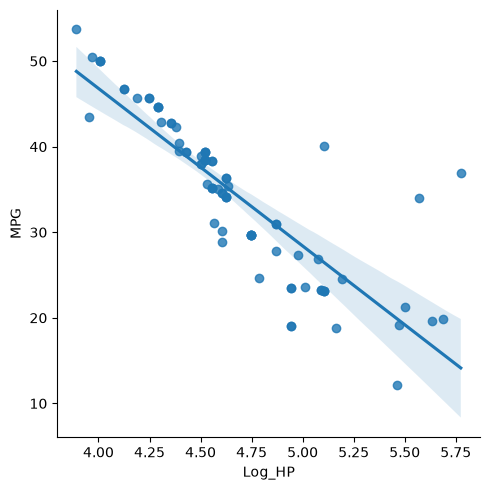

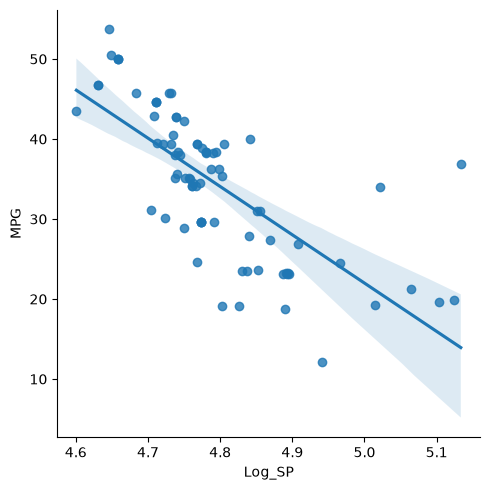

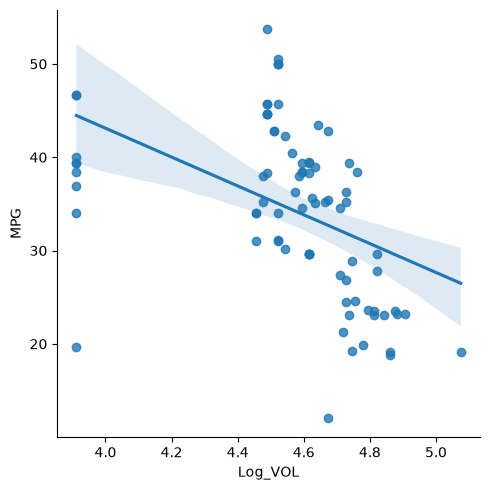

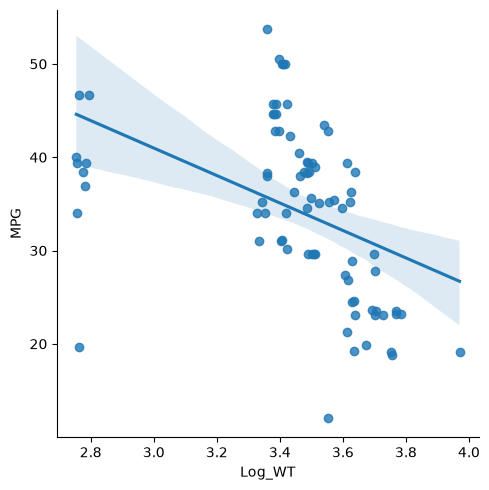

In [119]:
for i in car_df.columns:
    sns.lmplot(data=car_df,x=i,y="MPG")

In [120]:
x.shape

(81, 4)

In [121]:
x=car_df[["Log_HP","SP","VOL"]]
y=car_df["MPG"]
Model_2=LinearRegression()
Model_2.fit(x,y)
y_pred_train=Model_2.predict(x)


In [122]:
x.shape

(81, 3)

In [123]:
r2_score(y,y_pred_train)


0.9127312685751964

In [124]:
mean_absolute_error(y,y_pred_train)

1.6540965325800137

# to improve R2 score remove outliers

In [125]:
x.shape

(81, 3)

In [126]:
columns=["Log_HP","SP","VOL","MPG"]
for cols in columns:
    q1= car_df[cols].quantile(0.25)
    q3= car_df[cols].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    car_df=car_df[(car_df[cols]>=lower)&(car_df[cols]<=upper)]

In [127]:
car_df.reset_index(inplace=True)
car_df

,index,HP,MPG,VOL,SP,WT,Log_HP,Log_SP,Log_VOL,Log_WT
0,0,49,53.700681,89,104.185353,28.762059,3.891820,4.646172,4.488636,3.359057
1,1,55,50.013401,92,105.461264,30.466833,4.007333,4.658344,4.521789,3.416639
2,2,55,50.013401,92,105.461264,30.193597,4.007333,4.658344,4.521789,3.407630
3,3,70,45.696322,92,113.461264,30.632114,4.248495,4.731461,4.521789,3.422049
4,4,53,50.504232,92,104.461264,29.889149,3.970292,4.648816,4.521789,3.397495
...,...,...,...,...,...,...,...,...,...,...
62,68,165,23.103172,123,133.312342,40.472042,5.105945,4.892695,4.812184,3.700611
63,71,162,23.203569,135,133.415985,44.013139,5.087596,4.893472,4.905275,3.784488
64,72,162,23.203569,132,133.140074,43.353123,5.087596,4.891402,4.882802,3.769379
65,74,140,19.086341,129,121.864163,42.618698,4.941642,4.802907,4.859812,3.752293


In [70]:
del car_df["index"]

In [128]:
x=car_df[["Log_HP","SP","VOL"]]
y=car_df["MPG"]


In [129]:
Final_Model=LinearRegression()

In [130]:
x.shape

(67, 3)

In [131]:
Final_Model.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[-38.93, 0.65, -0.09]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Log_HP','SP','VOL']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,146.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [133]:
y_train_pred=Final_Model.predict(x)

In [134]:
r2_score(y,y_train_pred)

0.9831486200683976

In [136]:
mean_absolute_error(y,y_train_pred)

0.7797263121248754

In [137]:
import joblib
joblib.dump(Final_Model,"F_model.pkl")

['F_model.pkl']